<a href="https://colab.research.google.com/github/DikozWorld/Chisl-metods-labs/blob/main/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- МЕТОД КОЛЛОКАЦИЙ ---
c1 = -0.627558, c2 = -0.005477

--- МЕТОД ГАЛЕРКИНА ---
c1 = -0.616224, c2 = -0.000135

--- ТАБЛИЦА ЗНАЧЕНИЙ ---
      x  y (Коллокации)  y (Галеркин)  Разница
0.00000         1.00000       1.00000  0.00000
0.10000         0.94347       0.94454  0.00107
0.20000         0.89942       0.90140  0.00198
0.30000         0.86787       0.87058  0.00272
0.40000         0.84886       0.85209  0.00323
0.50000         0.84243       0.84593  0.00350
0.60000         0.84860       0.85209  0.00349
0.70000         0.86741       0.87057  0.00317
0.80000         0.89889       0.90139  0.00250
0.90000         0.94308       0.94453  0.00145
1.00000         1.00000       1.00000  0.00000


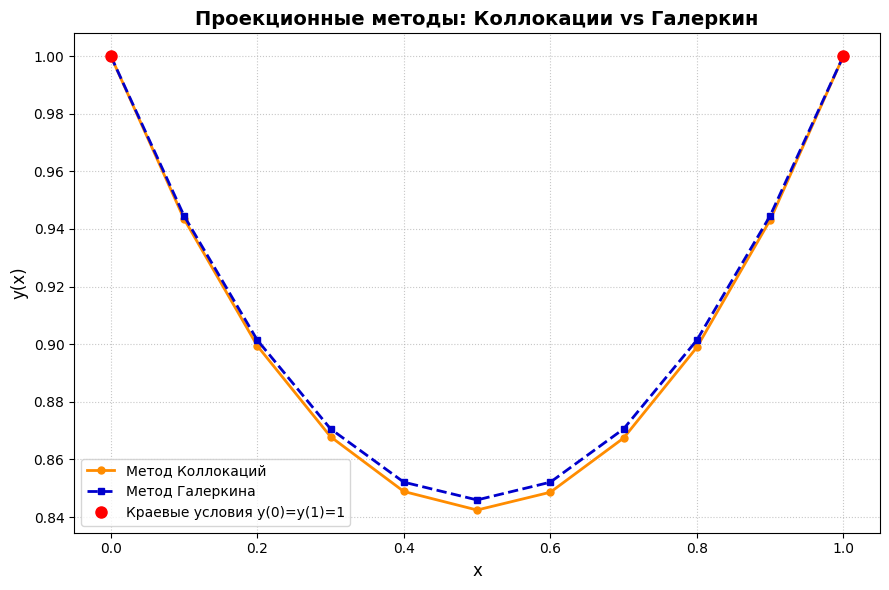

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad

# 1. ОБЩИЕ ФУНКЦИИ И БАЗИС (Вариант: y'' + x^2 y' - xy = cos(x), y(0)=y(1)=1)

# Базисные функции u1(x) и u2(x)
def u1(x): return x - x**2
def u2(x): return x**2 - x**3

# Результат подстановки базиса в дифференциальный оператор L[u]
def Lu1(x): return -2 - x**3
def Lu2(x): return 2 - 6*x + x**3 - 2*x**4

# Правая часть уравнения (с учетом переноса L[y0], где y0 = 1)
def rhs(x): return np.cos(x) + x

# 2. МЕТОД КОЛЛОКАЦИЙ
x1 = 1.0 / 3.0
x2 = 2.0 / 3.0

M_colloc = np.array([
    [Lu1(x1), Lu2(x1)],
    [Lu1(x2), Lu2(x2)]
])
B_colloc = np.array([rhs(x1), rhs(x2)])
c_colloc = np.linalg.solve(M_colloc, B_colloc)

print("--- МЕТОД КОЛЛОКАЦИЙ ---")
print(f"c1 = {c_colloc[0]:.6f}, c2 = {c_colloc[1]:.6f}")

# 3. МЕТОД ГАЛЕРКИНА (через интегралы)
# Вычисляем матрицу системы через определенные интегралы (quad возвращает значение и погрешность, берем [0])
A11 = quad(lambda x: Lu1(x) * u1(x), 0, 1)[0]
A12 = quad(lambda x: Lu2(x) * u1(x), 0, 1)[0]
A21 = quad(lambda x: Lu1(x) * u2(x), 0, 1)[0]
A22 = quad(lambda x: Lu2(x) * u2(x), 0, 1)[0]

B1 = quad(lambda x: rhs(x) * u1(x), 0, 1)[0]
B2 = quad(lambda x: rhs(x) * u2(x), 0, 1)[0]

M_galerkin = np.array([[A11, A12], [A21, A22]])
B_galerkin = np.array([B1, B2])
c_galerkin = np.linalg.solve(M_galerkin, B_galerkin)

print("\n--- МЕТОД ГАЛЕРКИНА ---")
print(f"c1 = {c_galerkin[0]:.6f}, c2 = {c_galerkin[1]:.6f}")

# 4. СРАВНИТЕЛЬНАЯ ТАБЛИЦА И ГРАФИКИ
# Сетка для таблицы и графиков
x_grid = np.linspace(0, 1, 11)

def calc_solution(c, x):
    return 1 + c[0]*u1(x) + c[1]*u2(x)

y_colloc = calc_solution(c_colloc, x_grid)
y_galerkin = calc_solution(c_galerkin, x_grid)

# Таблица
df = pd.DataFrame({
    'x': x_grid,
    'y (Коллокации)': y_colloc,
    'y (Галеркин)': y_galerkin,
    'Разница': np.abs(y_colloc - y_galerkin)
})
print("\n--- ТАБЛИЦА ЗНАЧЕНИЙ ---")
print(df.to_string(index=False, float_format=lambda val: f"{val:.5f}"))

# График
plt.figure(figsize=(9, 6), dpi=100)
plt.plot(x_grid, y_colloc, 'o-', color='darkorange', label='Метод Коллокаций', linewidth=2, markersize=5)
plt.plot(x_grid, y_galerkin, 's--', color='mediumblue', label='Метод Галеркина', linewidth=2, markersize=5)

plt.title('Проекционные методы: Коллокации vs Галеркин', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('y(x)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

# Точки краевых условий
plt.plot([0, 1], [1, 1], 'ro', markersize=8, label='Краевые условия y(0)=y(1)=1')
plt.legend()

plt.tight_layout()
plt.savefig('projection_methods.png')
plt.show()